# BÁO CÁO: PHÁT HIỆN VÀ GIẢI MÃ QR CODE DẠNG OBB (Oriented Bounding Box)
Họ tên: Nguyễn Ngọc Bình An  
Mã sinh viên: 2402247  
Mã học phần: AIT_3002#  
### Tổng quan: Báo cáo sau trình bày về phương pháp phát hiện và giải mã QR-CODE trong ảnh môi trường thực tế

---  
## 1. Mô tả phương pháp

### 1.1. Tiền xử lý ảnh (Image Preprocessing)

Quá trình tiền xử lý trước khi đưa vào mô hình AI tập trung vào việc chuẩn hóa kích thước đầu vào mà không làm biến dạng hình học của QR code.

* **Letterbox Resize (`preprocess_image`):** * Mô hình YOLO thường yêu cầu đầu vào là ảnh vuông (ở đây là `INFER_SIZE = 640`). Tuy nhiên, thay vì bóp méo ảnh (resize trực tiếp) làm thay đổi tỷ lệ khung hình của QR code, thuật toán tính toán tỷ lệ thu phóng `scale` sao cho cạnh lớn nhất vừa bằng 640.
    * Phần không gian còn thừa sẽ được thêm padding (viền xám với giá trị pixel `114`). Việc dùng màu xám trung tính giúp mô hình không bị nhiễu bởi các cạnh viền giả tạo ra do viền đen/trắng.
* **Phục hồi tọa độ (`undo_preprocess`):**
    * Sau khi mô hình dự đoán ra tọa độ bounding box trên ảnh canvas 640x640, hàm này sẽ loại bỏ phần padding và chia lại cho tỷ lệ `scale` để ánh xạ tọa độ dự đoán về đúng vị trí và kích thước trên ảnh gốc.
* **Chuẩn hóa thứ tự các góc (`order_points`):**
    * Mô hình OBB (Oriented Bounding Box) trả về 4 điểm nhưng thứ tự có thể lộn xộn. Hàm này sắp xếp 4 điểm theo đúng chuẩn đồng hồ: **Top-Left (trên trái) → Top-Right (trên phải) → Bottom-Right (dưới phải) → Bottom-Left (dưới trái)**.
    * Thuật toán sử dụng tổng (`x + y`) và hiệu (`x - y`) của các tọa độ:
        * Điểm có `x + y` nhỏ nhất là góc trên-trái.
        * Điểm có `x + y` lớn nhất là góc dưới-phải.
        * Điểm có `x - y` nhỏ nhất là góc trên-phải.
        * Điểm có `x - y` lớn nhất là góc dưới-trái.


### 1.2. Phát hiện vùng chứa QR code (QR Code Region Detection)

Phần này chịu trách nhiệm định vị chính xác vị trí của mã QR trong không gian 2D, hỗ trợ tính toán nghiêng xoay.

* **Sử dụng YOLO OBB (Oriented Bounding Box):** * Thay vì dùng Bounding Box ngang (HBB) thông thường, hệ thống dùng YOLO OBB (`obb.xyxyxyxy`). Điều này cực kỳ quan trọng vì QR code thường bị chụp nghiêng. OBB bám sát vào 4 mép của QR code, giúp loại bỏ tối đa nhiễu nền (background) xung quanh.
* **Quá trình suy luận (Inference):**
    * Ảnh canvas được đẩy qua mô hình YOLO với hai ngưỡng lọc nhiễu: `CONF_THRESHOLD = 0.25` (chỉ lấy các dự đoán có độ tin cậy > 25%) và `IOU_THRESHOLD = 0.45` (loại bỏ các bounding box trùng lặp qua kỹ thuật Non-Maximum Suppression).
* **Ưu tiên độ tin cậy:** * Các hộp giới hạn (boxes) được sắp xếp theo thứ tự độ tin cậy (`conf`) giảm dần. Điều này đảm bảo thuật toán sẽ ưu tiên xử lý và giải mã các mã QR rõ nét nhất trước.


### 1.3. Giải mã nội dung QR code (QR Code Content Decoding)

Đây là module phức tạp và được thiết kế theo dạng **Cascade (thác đổ)** kết hợp **Brute-force (thử sai)** để tối đa hóa khả năng đọc (Recall) trong các điều kiện khắc nghiệt nhất. Chiến lược được thực hiện qua các bước:

**A. Chuẩn hóa hình học (Geometry Standardization):**
Mã QR lấy từ ảnh gốc thường bị méo phối cảnh (perspective distortion) do góc chụp.
* **Pass 1 - Perspective Warp (`_warp_qr`):** Sử dụng 4 điểm góc đã sắp xếp để tính ma trận biến đổi phối cảnh (`cv2.getPerspectiveTransform`), sau đó nắn phẳng vùng QR code về một ảnh vuông hoàn hảo (thử nghiệm với 2 kích thước 256x256 và 512x512). 
* **Pass 2 - Bounding Box Crop (Fallback):** Nếu quá trình warp bị lỗi làm hỏng cấu trúc mã QR (do dự đoán điểm của AI bị lệch nhẹ), hệ thống chuyển sang phương án dự phòng: Cắt một vùng hình chữ nhật bao quanh QR code (mở rộng thêm `margin = 8` pixel) để giải mã.
* **Scale Up (`_scale_up`):** Nếu QR code cắt ra quá nhỏ (cạnh < 64 pixel), nó sẽ được phóng to bằng nội suy Bicubic lên 256 pixel để các thuật toán dò tìm góc (Finder Patterns) của bộ giải mã hoạt động dễ dàng hơn.

**B. Đa dạng hóa bộ lọc ảnh (Binarization Variants):**
Ánh sáng yếu, bóng râm, hoặc camera mờ có thể làm các bộ giải mã thất bại. Hàm `_binarize_variants` tạo ra 7 phiên bản ảnh khác nhau để quét nghiệm:
1.  **Grayscale gốc:** Dành cho các ảnh đã có chất lượng tốt.
2.  **CLAHE + Sharpen:** Tăng cường độ tương phản cục bộ trên kênh L (để xử lý chênh lệch ánh sáng/bóng râm) và dùng Unsharp Mask để làm sắc nét các module (các ô vuông nhỏ) của QR.
3.  **Otsu Threshold:** Nhị phân hóa toàn cục, hiệu quả khi nền và QR có độ tương phản rõ ràng.
4.  **Adaptive Mean Threshold:** Nhị phân hóa cục bộ, cực kỳ tốt cho ảnh bị tối một nửa hoặc nhiễu sáng không đều.
5.  **Adaptive Gaussian Threshold:** Tương tự Mean nhưng mượt mà hơn ở các cạnh.
6.  **CLAHE + Otsu:** Kết hợp cân bằng sáng trước rồi mới nhị phân hóa cứng.
7.  **Invert (Đảo màu):** Xử lý trường hợp "Negative QR" (mã QR có màu sáng in trên nền tối).

**C. Xoay ảnh (Rotation Variants):**
Nhiều thư viện giải mã truyền thống chỉ đọc được QR khi góc quét đúng chuẩn. Hệ thống tự động tạo thêm 3 phiên bản xoay (90°, 180°, 270°) cho mỗi bức ảnh đã lọc ở bước trên.

**D. Đa Backend Giải mã (Cascade Backend):**
Hệ thống không phụ thuộc vào một công cụ đọc QR duy nhất mà áp dụng 3 thư viện từ nhẹ đến mạnh (`_BACKENDS`):
1.  **OpenCV (`_try_cv2`):** Dùng `cv2.QRCodeDetectorAruco` (thuật toán mới và ổn định hơn dựa trên tag Aruco), backup bằng `cv2.QRCodeDetector` cũ.
2.  **PyZbar (`_try_pyzbar`):** Một trong những thư viện đọc barcode/QR mã nguồn mở tốt nhất, chạy rất nhanh.
3.  **ZXing (`_try_zxing`):** Chuyển thể từ thư viện Java nổi tiếng của Google, có khả năng sửa lỗi tốt (Error Correction) đối với các QR bị xước hoặc mờ một phần.

**Cơ chế Early-exit:** Vòng lặp sẽ thử chéo: [Các bộ lọc] $\times$ [Các góc xoay] $\times$ [Các backend]. Ngay khi có một tổ hợp trả về được chuỗi ký tự hợp lệ, quá trình tìm kiếm sẽ dừng ngay lập tức (return) để tối ưu thời gian chạy thực tế (FPS).

---

---
## 2 Chi tiết
### 2.1. Tổng quan về project

QR_Project/
├── main.py                  # Script chạy chính (Inference & Evaluation)  
├── main.ipynb                # File báo cáo & huấn luyện mô hình  
├── main.ipynb                # File báo cáo & huấn luyện mô hình  
├── requirements.txt         # Danh sách các thư viện cần thiết (ultralytics, opencv, pyzbar...)  
├── output.csv           # File kết quả dự đoán tọa độ & nội dung QR  
├── qr/                      # Vùng chứa dữ liệu đầu vào (Data Layer)  
│   ├── images/              # Thư mục chứa toàn bộ ảnh (.jpg, .png)  
│   ├── public_train.csv     # File dữ liệu huấn luyện / đầu vào cho test  
│   └── output_train.csv     # File Ground-Truth (GT) chuẩn dùng để đánh giá  
│   ├── public_valid.csv     # File dữ liệu đánh giá / đầu vào cho test  
│   └── output_valid.csv     # File Ground-Truth (GT) chuẩn dùng để đánh giá  
│  
├── runs/                    # Vùng chứa kết quả mô hình (Model Layer)  
    └── obb/                 # Chuẩn đầu ra của YOLO cho Oriented Bounding Box  
        └── QR_OBB_Training/  
            └── run_v1/  
                ├── weights/  
                │   ├── best.pt  # Trọng số tốt nhất (DEFAULT_MODEL)  
                │   └── last.pt  # Trọng số ở epoch cuối  
                ├── results.csv  # Bảng theo dõi loss/metrics qua các epoch  
                └── (các file đồ thị dự đoán, PR-curve, F1-curve...)  

### 2.2. Các thư viện chính được sử dụng
#### 2.2.1. Nhóm Xử lý Ảnh & Trí tuệ Nhân tạo (Computer Vision & AI)

Đây là "trái tim" của toàn bộ mã nguồn, chịu trách nhiệm nhìn, nhận diện và tinh chỉnh hình ảnh.

* **`cv2` (OpenCV - Open Source Computer Vision Library):**
    * *Tác dụng:* Thư viện lõi dùng để thao tác với ảnh ở mức độ pixel.
    * *Ứng dụng trong code:*
        * Đọc/ghi ảnh (`cv2.imread`).
        * Chuyển đổi không gian màu (BGR sang Grayscale, LAB).
        * Tăng cường ảnh: Tối ưu tương phản cục bộ (`cv2.createCLAHE`), làm nét (`cv2.GaussianBlur`, `cv2.addWeighted`), và khử nhiễu (`cv2.fastNlMeansDenoising`).
        * Nắn chỉnh phối cảnh (Perspective Warp) để lật vuông QR code (`cv2.getPerspectiveTransform`, `cv2.warpPerspective`).
        * Đóng vai trò là một backend giải mã QR dự phòng (`cv2.QRCodeDetectorAruco`).
* **`ultralytics` (`YOLO`):**
    * *Tác dụng:* Framework mạnh mẽ để triển khai các mô hình YOLO thế hệ mới.
    * *Ứng dụng trong code:* Khởi tạo và chạy mô hình suy luận (`model.predict()`) để trích xuất tọa độ Oriented Bounding Box (OBB) của QR code trên ảnh.

#### 2.2.2. Nhóm Tính toán Toán học & Xử lý Dữ liệu (Math & Data Handling)

Nhóm này xử lý các con số, tọa độ hình học và quản lý tệp dữ liệu dạng bảng.

* **`numpy` (`import numpy as np`):**
    * *Tác dụng:* Thư viện tính toán ma trận và mảng đa chiều tốc độ cao.
    * *Ứng dụng trong code:* Ảnh trong OpenCV bản chất là mảng Numpy. Numpy được dùng để tính toán tọa độ góc (`np.argmin`, `np.argmax`), nội suy diện tích đa giác để tính mốc đánh giá IoU (`np.dot`, `np.roll`), và tạo ảnh nền đen/xám cho padding (`np.full`, `np.zeros`).
* **`pandas` (`import pandas as pd`):**
    * *Tác dụng:* Công cụ thao tác với dữ liệu dạng bảng (Dataframe) cực kỳ tối ưu.
    * *Ứng dụng trong code:* Đọc file CSV đầu vào (chứa đường dẫn ảnh) và file CSV Ground Truth (chứa tọa độ gốc để đánh giá) thông qua `pd.read_csv`. Duyệt qua các hàng dữ liệu (`df.iterrows()`).
* **`csv`:**
    * *Tác dụng:* Module mặc định của Python để làm việc với file CSV.
    * *Ứng dụng trong code:* Dùng để ghi kết quả dự đoán (tọa độ, nội dung QR) và bảng đánh giá chi tiết (Metrics) ra file output (`csv.DictWriter`). Nó nhẹ hơn Pandas khi chỉ cần thao tác ghi file đơn giản ở bước cuối.

#### 2.2.3. Nhóm Giao diện Dòng lệnh & Tiện ích Hệ thống (CLI & System Utilities)

Nhóm này giúp mã nguồn trở thành một phần mềm độc lập, có thể điều khiển qua Terminal/Command Line thay vì phải sửa code mỗi lần chạy.

* **`argparse`:**
    * *Tác dụng:* Phân tích các đối số (arguments) truyền vào từ dòng lệnh.
    * *Ứng dụng trong code:* Tạo ra các cờ lệnh như `--data` (chọn file CSV), `--model` (chọn trọng số), `--eval-only` (chỉ đánh giá), giúp pipeline linh hoạt cho cả việc huấn luyện, suy luận và kiểm thử.
* **`os` & `pathlib` (`from pathlib import Path`):**
    * *Tác dụng:* Quản lý đường dẫn file và thư mục, tương thích đa nền tảng (Windows/Linux/macOS).
    * *Ứng dụng trong code:* Nối chuỗi đường dẫn ảnh, kiểm tra xem file ảnh có tồn tại thực sự hay không (`os.path.exists`), và kiểm tra đường dẫn là tuyệt đối hay tương đối (`os.path.isabs`). `Path` giúp code nhìn sạch sẽ và chuẩn Pythonic hơn.
* **`time`:**
    * *Tác dụng:* Xử lý các tác vụ liên quan đến thời gian.
    * *Ứng dụng trong code:* Đo lường tốc độ xử lý (FPS) của mô hình. Đặt mốc `time.time()` ở đầu và cuối vòng lặp để tính ra "Số giây/ảnh trung bình", một chỉ số quan trọng khi đánh giá hiệu năng deploy thực tế.

#### 2.2.4. Nhóm Hỗ trợ Thử nghiệm & Trực quan hóa (EDA & Visualization)

* **`matplotlib.pyplot` & `matplotlib.gridspec`:**
    * *Tác dụng:* Vẽ biểu đồ và hiển thị hình ảnh.
    * *Ứng dụng:* Dùng để xem trước ảnh (show image), hiển thị các bounding box vẽ đè lên ảnh để kiểm tra bằng mắt thường (debug), hoặc vẽ biểu đồ so sánh Loss/Metrics trong quá trình train YOLO.
* **`IPython.display` (`Image`, `display`):**
    * *Tác dụng:* Trực quan hóa trực tiếp bên trong môi trường Jupyter/Colab.
    * *Ứng dụng:* Hiển thị nhanh các bức ảnh kết quả mà không cần popup cửa sổ mới như `cv2.imshow()`.
* **`shutil`, `random`, `yaml`:**
    * *Tác dụng:* Quản lý file nâng cao, ngẫu nhiên hóa và tệp cấu hình.
    * *Ứng dụng:* Dùng trong quá trình chuẩn bị dữ liệu (chia tập Train/Val ngẫu nhiên bằng `random`, copy file sang thư mục mới bằng `shutil`) và thao tác với tệp cấu hình `data.yaml` của YOLO (thông qua `yaml`).

---

## 2.3. Mô hình 

### 2.3.1. Mô hình được sử dụng

#### 2.3.1.1. Sơ bộ về mô hình yolo-v8n-obb
Trong dự án này, mô hình được lựa chọn là **YOLOv8n-OBB** (You Only Look Once version 8 Nano - Oriented Bounding Box) thuộc framework Ultralytics. 

Khác với các mô hình phát hiện đối tượng truyền thống sử dụng hộp giới hạn song song với trục tọa độ (Horizontal Bounding Box - HBB) định dạng $(x, y, w, h)$, mô hình OBB dự đoán các hộp giới hạn có khả năng xoay nghiêng. Đầu ra của mô hình bổ sung thêm tham số góc xoay $\theta$, định dạng tọa độ thành $(x, y, w, h, \theta)$ hoặc dự đoán trực tiếp tọa độ 4 đỉnh $(x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4)$. 

Phiên bản "nano" (v8n) là phiên bản có kích thước tham số nhỏ nhất trong họ YOLOv8, được thiết kế tối ưu hóa về mặt tính toán nhằm cân bằng giữa độ chính xác (mAP) và tốc độ suy luận (FPS).

#### 2.3.1.2. Lý do chọn mô hình
Việc lựa chọn YOLOv8n-OBB dựa trên hai yêu cầu đặc thù của bài toán:

1.  **Tính chất hình học của QR Code:** Mã QR trong môi trường thực tế (được quét từ camera điện thoại, camera an ninh, hoặc trên băng chuyền công nghiệp) hiếm khi nằm thẳng hàng với trục tọa độ của ảnh. Nếu sử dụng HBB thông thường, hộp giới hạn sẽ chứa rất nhiều nhiễu nền (background) xung quanh khi QR bị đặt chéo, gây khó khăn cho module giải mã phía sau. OBB bám sát chặt chẽ vào 4 mép của mã QR bất chấp góc nghiêng, giúp việc cắt (crop) và nắn chỉnh phối cảnh (perspective warp) chính xác tuyệt đối.
2.  **Tối ưu cho triển khai thời gian thực (Real-time Edge Deployment):** Đối với các ứng dụng quét mã, tốc độ phản hồi là yếu tố sống còn. Kiến trúc tham số siêu nhẹ của YOLOv8n kết hợp với việc xuất khẩu (export) sang định dạng ONNX (Open Neural Network Exchange) ở cuối quy trình huấn luyện cho phép mô hình dễ dàng triển khai trên các thiết bị biên (edge devices) có tài nguyên phần cứng hạn chế mà vẫn duy trì được tốc độ suy luận cao (được minh chứng qua hàm `run_camera_test`).

### 2.3.2. Huấn luyện mô hình

#### 2.3.2.1. Lý thuyết về huấn luyện mô hình
Quá trình huấn luyện áp dụng kỹ thuật Transfer Learning (học chuyển giao), khởi tạo bằng các trọng số đã được huấn luyện sẵn `yolov8n-obb.pt` để tăng tốc độ hội tụ. Hàm mất mát (Loss Function) của YOLOv8-OBB được theo dõi qua 3 thành phần chính:
* **Box Loss:** Đo lường sai số về tọa độ và kích thước hộp giới hạn dự đoán so với nhãn thực tế.
* **Cls Loss (Classification Loss):** Đo lường sai số phân loại (ở bài toán này chỉ có 1 lớp duy nhất là `qr_code`).
* **DFL Loss (Distribution Focal Loss):** Giúp mô hình học được sự phân bố tinh vi của các cạnh, làm mịn các dự đoán cận biên.

Quá trình cập nhật trọng số sử dụng thuật toán lan truyền ngược (Backpropagation) để tối thiểu hóa tổng các hàm mất mát này.

#### 2.3.2.2. Tính chất của tập dữ liệu
Dữ liệu đóng vai trò quyết định đến độ bền vững (robustness) của mô hình. Trong mã nguồn, tập dữ liệu đầu vào được chia theo tỷ lệ 80/20 (80% Train, 20% Validation) thông qua hàm `process_dataset`.

Đặc điểm nổi bật nhất là việc tự xây dựng một quy trình **Data Augmentation tùy chỉnh (Custom Augmentation)** cực kỳ đa dạng để ép mô hình học cách nhận diện QR trong điều kiện khắc nghiệt, nhân bản dữ liệu Train lên 6 lần (`AUGMENT_FACTOR = 6`). Các kỹ thuật nhiễu loạn được áp dụng theo xác suất (`random.random()`) bao gồm:
1.  **Nhiễu loạn màu sắc & Ánh sáng (Photometric):** Thay đổi ngẫu nhiên không gian màu HSV (Hue, Saturation, Value), hoán đổi kênh màu (Channel Shuffle), đảo ngược màu (Invert), biến đổi độ sáng/tương phản ($\alpha$ và $\beta$).
2.  **Nhiễu loạn cấu trúc & Cảm biến:** Thêm nhiễu Gaussian (mô phỏng ảnh chụp đêm thiếu sáng), làm mờ Motion Blur/Gaussian Blur (mô phỏng rung tay khi quét), nén ảnh JPEG chất lượng thấp, và Random Cutout (tạo các lỗ hổng đen che khuất ngẫu nhiên một phần QR code để ép mô hình phải nhận diện dựa trên phần còn lại).
3.  **Biến đổi hình học (Geometric):** Xoay ảnh từ $0^\circ$ đến $360^\circ$ và tịnh tiến ($dx, dy$). Tọa độ OBB gốc được nhân với ma trận nội suy (`transform_point` với ma trận $M$) để tọa độ nhãn luôn di chuyển khớp với hình ảnh mã QR mới.

#### 2.3.2.3. Các bước huấn luyện
Quy trình huấn luyện được thực thi hoàn toàn tự động qua các bước sau:

1.  **Chuẩn bị cấu hình:** Mã nguồn tạo file `data.yaml` để định tuyến đường dẫn tuyệt đối cho tập Train/Val và khai báo số lượng lớp (1 lớp: `qr_code`).
2.  **Thiết lập siêu tham số (Hyperparameters):** Mô hình được gọi qua lệnh `model.train()` với cấu hình: 
    * `epochs = 100`: Số vòng lặp tối đa qua toàn bộ tập dữ liệu.
    * `batch = 32`: Kích thước lô cập nhật trọng số.
    * `imgsz = 640`: Kích thước ảnh đầu vào.
    * `patience = 10`: Cơ chế Early Stopping, dừng huấn luyện nếu sau 10 epoch chỉ số kiểm định không cải thiện để tránh Overfitting.
3.  **Vô hiệu hóa Augmentation mặc định:** Do tập dữ liệu đã được tăng cường thủ công ở mức độ rất phức tạp, toàn bộ các tham số Augmentation nội tại của YOLO (như `hsv_h`, `degrees`, `mosaic`, `mixup`, v.v.) đều được đặt về `0.0`. Điều này giúp kiểm soát chính xác 100% dữ liệu đi vào mạng.
4.  **Đánh giá & Triển khai:** Xuyên suốt quá trình, các chỉ số mAP@50, Precision, Recall và Loss được lưu vào `results.csv` và trực quan hóa qua Dashboard bằng `matplotlib`. Trọng số hội tụ tốt nhất (`best.pt`) cuối cùng được xuất ra định dạng `best.onnx` (`opset=12`) để sử dụng trực tiếp cho bước Inference thực tế.

#### 2.3.2.4 Quy trình huấn luyện
1. Chuẩn bị thư viện

In [1]:
import os, shutil, random, time, yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from ultralytics import YOLO
import ultralytics
from IPython.display import Image, display

2. Xác định các tham số chính chuẩn bị cho bước huấn luyện

In [2]:
DATASET_ROOT   = "datasets/qr_obb"
CLASS_NAME     = "qr_code"
AUGMENT_FACTOR = 6
RUN_NAME       = "run_v1"
PROJECT        = "QR_OBB_Training"
BEST_PT        = f"./runs/obb/{PROJECT}/{RUN_NAME}/weights/best.pt"
BEST_ONNX      = f"./runs/obb/{PROJECT}/{RUN_NAME}/weights/best.onnx"

3. Setup folder chứa dữ liệu huấn luyện

In [3]:
def setup_dirs(force_clear=True):
    if force_clear and os.path.exists(DATASET_ROOT):
        shutil.rmtree(DATASET_ROOT)
    for split in ['train', 'val']:
        for sub in ['images', 'labels']:
            Path(os.path.join(DATASET_ROOT, split, sub)).mkdir(parents=True, exist_ok=True)
    Path(os.path.join(DATASET_ROOT, "debug")).mkdir(parents=True, exist_ok=True)
    print(f"[*] Đã khởi tạo thư mục: {DATASET_ROOT}")

In [4]:
setup_dirs(force_clear=True)

[*] Đã khởi tạo thư mục: datasets/qr_obb


4. Các hàm cho quá trình dịch chuyển tọa độ điểm
* Khi áp dụng Data Augmentation (đặc biệt là xoay và dịch chuyển ảnh), vị trí của QR code bị thay đổi nên tọa độ nhãn (label) cũng phải được cập nhật tương ứng
    * transform_point(x, y, M): Áp dụng ma trận biến đổi Affine M lên tọa độ cũ (x, y) để tìm ra tọa độ mới của các góc QR code sau khi ảnh đã bị xoay hoặc tịnh tiến.
    * is_box_inside_image: Bộ lọc kiểm tra an toàn. Hàm này đánh giá xem cả 4 góc của hộp giới hạn (OBB) sau khi biến đổi có còn nằm hoàn toàn trong khung ảnh (width x height) hay không. Nếu bị văng ra ngoài mép ảnh, nhãn đó sẽ bị loại bỏ để tránh sinh ra dữ liệu lỗi khi huấn luyện.



In [5]:
def transform_point(x, y, M):
    return M[0,0]*x + M[0,1]*y + M[0,2], M[1,0]*x + M[1,1]*y + M[1,2]

def is_box_inside_image(obb_pts, img_w, img_h):
    return all(0 <= x < img_w and 0 <= y < img_h for x, y in obb_pts)

5. Hàm tăng cường dữ liệu quang học (Photometric Augmentation)

Hàm `apply_photometric_augmentation` tạo ra các biến đổi đa dạng trên cấp độ điểm ảnh (pixel) dựa trên xác suất ngẫu nhiên. Việc này giúp mô phỏng các điều kiện quét mã QR khắc nghiệt trong thực tế mà không làm thay đổi hình học (tọa độ nhãn) của bức ảnh:

* **Biến đổi ánh sáng & màu sắc:** Điều chỉnh ngẫu nhiên không gian màu HSV, thay đổi độ sáng/tương phản ($\alpha, \beta$), đảo màu (Invert), hoặc chuyển sang ảnh đen trắng.
* **Mô phỏng nhiễu cảm biến (Noise & Artifacts):** Thêm nhiễu hạt Gaussian, nhiễu muối tiêu (Salt & Pepper), và nhiễu rỗ do nén ảnh JPEG chất lượng thấp.
* **Mô phỏng camera kém:** Áp dụng làm mờ Gaussian (mô phỏng camera mất nét) hoặc làm mờ chuyển động (Motion Blur - mô phỏng rung tay khi quét).
* **Che khuất cục bộ (Random Cutout):** Tạo ra các mảng màu ngẫu nhiên đè lên ảnh, mô phỏng tình huống mã QR bị dán đè, bị xước, bẩn hoặc có vật cản che khuất một phần.

In [ ]:
def apply_photometric_augmentation(img):
    aug = img.copy().astype(np.float32)
    h_img, w_img = aug.shape[:2]
    if random.random() < 0.5:
        hsv = cv2.cvtColor(np.clip(aug, 0, 255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:,:,0] = (hsv[:,:,0] + random.uniform(-30, 30)) % 180  # Thay đổi màu sắc lõi
        hsv[:,:,1] = np.clip(hsv[:,:,1] * random.uniform(0.5, 1.8), 0, 255) # Độ bão hòa
        hsv[:,:,2] = np.clip(hsv[:,:,2] * random.uniform(0.6, 1.4), 0, 255) # Độ sáng
        aug = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR).astype(np.float32)
    if random.random() < 0.2:
        channels = list(cv2.split(aug))
        random.shuffle(channels)
        aug = cv2.merge(channels)
    if random.random() < 0.1:
        aug = 255.0 - aug
    if random.random() < 0.4:
        alpha = random.uniform(0.6, 1.5)  
        beta = random.uniform(-30, 30)   
        aug = aug * alpha + beta

    aug = np.clip(aug, 0, 255).astype(np.uint8)
    if random.random() < 0.35:
        if random.random() < 0.5:
            k = random.choice([5, 7, 9]) 
            aug = cv2.GaussianBlur(aug, (k, k), 0)
        else:
            k = random.choice([5, 7, 9])
            kernel = np.zeros((k, k), np.float32)
            kernel[k//2, :] = 1.0 / k
            rm = cv2.getRotationMatrix2D((k/2, k/2), random.uniform(0, 180), 1)
            kernel = cv2.warpAffine(kernel, rm, (k, k))
            aug = cv2.filter2D(aug, -1, kernel)
    if random.random() < 0.3:
        noise = np.random.normal(0, random.uniform(10, 30), aug.shape).astype(np.float32)
        aug = np.clip(aug.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    if random.random() < 0.2:
        prob = random.uniform(0.01, 0.03) 
        mask = np.random.rand(h_img, w_img)
        aug[mask < (prob / 2)] = 0
        aug[(mask > (prob / 2)) & (mask < prob)] = 255
    if random.random() < 0.3:
        q = random.randint(15, 50)
        _, enc = cv2.imencode('.jpg', aug, [cv2.IMWRITE_JPEG_QUALITY, q])
        aug = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if random.random() < 0.5:
        n_holes = random.randint(1, 4) 
        for _ in range(n_holes):
            hole_w = int(w_img * random.uniform(0.05, 0.2))
            hole_h = int(h_img * random.uniform(0.05, 0.2))
            
            if hole_w > 0 and hole_h > 0:
                x = random.randint(0, max(1, w_img - hole_w))
                y = random.randint(0, max(1, h_img - hole_h))
                color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
                cv2.rectangle(aug, (x, y), (x + hole_w, y + hole_h), color, -1)

    if random.random() < 0.1:
        aug = cv2.cvtColor(cv2.cvtColor(aug, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)

    return aug

6. Pipeline Tăng cường và Lưu dữ liệu (Augmentation Pipeline)

Hàm `augment_and_save_sample` đóng vai trò là luồng thực thi chính để tạo, đồng bộ và lưu trữ một mẫu dữ liệu (sample) mới. Hàm này thực hiện 4 bước cốt lõi:

* **Biến đổi hình học (Geometric Transform):** Áp dụng ma trận Affine (để xoay `angle` và tịnh tiến `dx, dy`) lên bức ảnh gốc thông qua `cv2.warpAffine`.
* **Tích hợp nhiễu quang học:** Tự động gọi hàm làm nhiễu ánh sáng/màu sắc (đã trình bày ở trên) nếu bức ảnh đang được xử lý thuộc tập huấn luyện (Train) và không phải ảnh gốc.
* **Đồng bộ tọa độ nhãn (Label Sync):** Cập nhật tọa độ 4 góc của QR code theo cùng ma trận biến đổi của ảnh (`transform_point`). Quan trọng nhất, nó sẽ tự động loại bỏ các bounding box bị văng ra ngoài khung hình sau khi xoay/dịch chuyển để tránh dữ liệu rác.
* **Chuẩn hóa YOLO OBB & Xuất file:** Chuyển đổi tọa độ pixel về dải chuẩn hóa `[0, 1]` (chia cho width và height). Cuối cùng, hàm ghi nhãn ra file `.txt` (định dạng: `class_id x1 y1 x2 y2 x3 y3 x4 y4`) và lưu ảnh ra file `.jpg`. Có kèm chế độ `debug` để vẽ bounding box đè lên ảnh hỗ trợ kiểm tra trực quan.

In [7]:
def augment_and_save_sample(img, image_id, group, split, suffix,
                            angle=0, dx=0, dy=0, debug=False):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    M[0,2] += dx
    M[1,2] += dy
    img_aug = cv2.warpAffine(img, M, (w, h), borderValue=(0,0,0))

    if split == 'train' and suffix != '_orig':
        img_aug = apply_photometric_augmentation(img_aug)

    img_debug = img_aug.copy() if debug else None
    valid_lines = []

    if group is not None:
        for _, row in group.iterrows():
            if pd.isna(row['x0']):
                continue
            pts = [[*transform_point(row[f'x{i}'], row[f'y{i}'], M)] for i in range(4)]
            if not is_box_inside_image(pts, w, h):
                continue
            norm = []
            for p in pts:
                norm.extend([p[0]/w, p[1]/h])
            valid_lines.append(f"0 {' '.join(f'{v:.6f}' for v in norm)}\n")
            if debug:
                cv2.polylines(img_debug,
                              [np.array(pts, np.int32).reshape(-1,1,2)], True, (0,255,0), 2)
                for i, p in enumerate(pts):
                    cv2.putText(img_debug, str(i), (int(p[0]), int(p[1])),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

    if split == 'train' and not valid_lines:
        return False

    new_id = f"{image_id}{suffix}"
    cv2.imwrite(f"{DATASET_ROOT}/{split}/images/{new_id}.jpg", img_aug)
    with open(f"{DATASET_ROOT}/{split}/labels/{new_id}.txt", 'w') as f:
        f.writelines(valid_lines)
    if debug:
        cv2.imwrite(f"{DATASET_ROOT}/debug/{new_id}_debug.jpg", img_debug)
    return True

7. Quy trình Phân chia và Quản lý Dữ liệu (Dataset Processing)

Hàm `process_dataset` thực thi luồng kịch bản tổng thể để chuẩn bị tập dữ liệu đưa vào mô hình YOLO:

* **Chia tập dữ liệu (80/20):** Xáo trộn ngẫu nhiên danh sách ảnh gốc (`random.seed(42)` để kết quả luôn cố định ở các lần chạy khác nhau) và cắt ra 80% cho tập huấn luyện (Train), 20% cho tập kiểm định (Validation).
* **Xử lý tập Validation:** Giữ nguyên trạng thái tự nhiên của ảnh, chỉ gọi hàm để xuất nhãn ra đúng chuẩn YOLO OBB.
* **Xử lý tập Train (Tăng cường theo lô):** Với mỗi ảnh huấn luyện, hệ thống lưu lại một bản gốc (`_orig`), sau đó dùng vòng lặp để sinh thêm các phiên bản đa dạng (`AUGMENT_FACTOR`). Các bản copy này sẽ bị xoay góc ngẫu nhiên ($0^\circ - 360^\circ$) và dịch chuyển trục $x, y$ để ép mô hình học cấu trúc QR code từ mọi hướng.

In [8]:
def process_dataset(csv_path, src_img_dir):
    df = pd.read_csv(csv_path)
    all_images = [f.replace('.jpg','') for f in os.listdir(src_img_dir) if f.endswith('.jpg')]
    random.seed(42)
    random.shuffle(all_images)

    split_idx = int(len(all_images) * 0.8)
    train_imgs, val_imgs = all_images[:split_idx], all_images[split_idx:]
    grouped = df.groupby('image_id')

    print(f"[*] VAL: {len(val_imgs)} ảnh...")
    for img_id in val_imgs:
        img   = cv2.imread(os.path.join(src_img_dir, f"{img_id}.jpg"))
        group = grouped.get_group(img_id) if img_id in grouped.groups else None
        augment_and_save_sample(img, img_id, group, 'val', "")

    print(f"[*] TRAIN: {len(train_imgs)} ảnh gốc × {AUGMENT_FACTOR}...")
    count = 0
    for idx, img_id in enumerate(train_imgs):
        img = cv2.imread(os.path.join(src_img_dir, f"{img_id}.jpg"))
        if img is None: continue
        group    = grouped.get_group(img_id) if img_id in grouped.groups else None
        h, w     = img.shape[:2]
        is_debug = idx < 3

        augment_and_save_sample(img, img_id, group, 'train', "_orig", debug=is_debug)
        count += 1
        for i in range(1, AUGMENT_FACTOR):
            ok = augment_and_save_sample(
                img, img_id, group, 'train', f"_aug{i}",
                angle=random.uniform(0, 360),
                dx=random.uniform(-w*0.2, w*0.2),
                dy=random.uniform(-h*0.2, h*0.2),
                debug=is_debug
            )
            if ok: count += 1

    print(f"[*] Hoàn tất! Tổng ảnh train: {count}")


In [9]:
process_dataset('qr/output_train.csv', 'qr/train')

[*] VAL: 217 ảnh...
[*] TRAIN: 866 ảnh gốc × 6...
[*] Hoàn tất! Tổng ảnh train: 4161


### 8. Khởi tạo cấu hình dữ liệu (Dataset Configuration)

Hàm `create_obb_yaml` tự động sinh ra tệp `data.yaml` – đây là tệp cấu hình (config) bắt buộc phải có để framework Ultralytics (YOLO) hiểu được cấu trúc tập dữ liệu trước khi bắt đầu huấn luyện. Hàm thực hiện hai nhiệm vụ chính:

* **Định tuyến đường dẫn:** Trích xuất đường dẫn tuyệt đối (`abspath`) đến thư mục gốc chứa dữ liệu, đồng thời trỏ đúng đến các thư mục con chứa ảnh `train` và `val`. Điều này giúp hệ thống tránh được lỗi sai lệch đường dẫn khi chạy trên các môi trường máy tính khác nhau.
* **Định nghĩa lớp (Class Mapping):** Khai báo từ điển `names` để ánh xạ ID của nhãn (class `0`) với tên thực tế của đối tượng (là `"qr_code"`). Mô hình sẽ dùng thông tin này để hiển thị tên nhãn lên các bounding box khi dự đoán.

In [10]:
def create_obb_yaml():
    yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump({
            'path' : os.path.abspath(DATASET_ROOT),
            'train': 'train/images',
            'val'  : 'val/images',
            'names': {0: CLASS_NAME}
        }, f, default_flow_style=False, sort_keys=False)
    assert os.path.exists(yaml_path), "Tạo yaml thất bại!"
    print(f"[*] Đã tạo & xác nhận: {yaml_path}")

In [11]:
create_obb_yaml()

[*] Đã tạo & xác nhận: datasets/qr_obb/data.yaml


9. Kiểm tra cấu hình máy huấn luyện và thư viện huấn luyện `untralytics`

In [12]:
ultralytics.checks()

Ultralytics 8.4.33 🚀 Python-3.11.15 torch-2.4.0 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5764MiB)
Setup complete ✅ (16 CPUs, 30.1 GB RAM, 18.4/109.4 GB disk)


10. Thiết lập và Thực thi Huấn luyện (Model Training)

Đoạn mã này khởi động quá trình huấn luyện mạng YOLOv8n-OBB. Có hai điểm nhấn kỹ thuật quan trọng nhất trong cấu hình này:

* **Tối ưu hóa Siêu tham số (Hyperparameter Tuning):** * Kích thước ảnh đầu vào được chuẩn hóa ở mức `imgsz=640`.
    * Quá trình huấn luyện kéo dài tối đa `epochs=100` với kích thước lô `batch=32` trên GPU (`device=0`). 
    * Áp dụng cơ chế **Early Stopping** (`patience=10`): Nếu sau 10 epoch liên tiếp mà độ chính xác trên tập Validation không được cải thiện, hệ thống sẽ tự động dừng sớm để tiết kiệm thời gian và tránh hiện tượng học vẹt (Overfitting).
* **Vô hiệu hóa Augmentation nội tại (Zero-Augmentation Policy):**
    * Toàn bộ các tham số tăng cường dữ liệu mặc định của YOLO (như `hsv_h`, `mosaic`, `mixup`, `degrees`, `flip`,...) đều được ép về `0.0`. 
    * *Lý do:* Ở các bước trước, hệ thống đã tự xây dựng một pipeline Data Augmentation tùy chỉnh rất mạnh và chuyên biệt cho QR code. Việc tắt Augmentation của YOLO giúp kiểm soát tuyệt đối luồng dữ liệu đầu vào, tránh tình trạng "nhiễu chồng nhiễu" làm biến dạng hoặc phá hỏng cấu trúc nhãn OBB đã tính toán cẩn thận.

In [13]:
model = YOLO('yolov8n-obb.pt')
model.train(
        data       = f'{DATASET_ROOT}/data.yaml',
        epochs     = 100, imgsz=640, batch=32,
        patience   = 10,  device=0,
        project    = PROJECT, name=RUN_NAME,
        save       = True, verbose=True,
        hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
        degrees=0.0, translate=0.0, scale=0.0,
        shear=0.0, flipud=0.0, fliplr=0.0,
        mosaic=0.0, mixup=0.0, copy_paste=0.0,
    )
print(f"[*] Huấn luyện xong → {BEST_PT}")

New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.11.15 torch-2.4.0 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5764MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/qr_obb/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name

/home/sanng/miniconda3/envs/vision_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1526.0±796.1 MB/s, size: 107.5 KB)
val: Scanning /run/media/sanng/New Volume/Window/Python/QR_DETECTION/datasets/qr_obb/val/labels... 217 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 217/217 2.6Kit/s 0.1s
val: New cache created: /run/media/sanng/New Volume/Window/Python/QR_DETECTION/datasets/qr_obb/val/labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 63 weight(decay=0.0), 73 weight(decay=0.0005), 72 bias(decay=0.0)
Plotting labels to /run/media/sanng/New Volume/Window/Python/QR_DETECTION/runs/obb/QR_OBB_Training/run_v1/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /run/media/sanng/New Volume/Window/Python/QR_DETECTION/runs/obb/QR_OBB_Training/run_v1
Starting training for 100 epochs...

      Epoch    GPU_mem   b

---

### 2.4. Các thuật toán xử lý ảnh

Trong dự án này, bên cạnh việc sử dụng Deep Learning để phát hiện vị trí (YOLO-OBB), các thuật toán xử lý ảnh kỹ thuật số (Digital Image Processing) truyền thống đóng vai trò cốt lõi trong việc "cứu" các mã QR bị mờ, lóa sáng hoặc nhiễu trước khi đưa vào bộ giải mã.

#### 2.4.1. Khử nhiễu giữ cạnh (Fast Non-Local Means Denoising)

**Nguyên lý:** Khác với các bộ lọc thông thường (như Median hay Mean filter) chỉ lấy trung bình các điểm ảnh lân cận, thuật toán **Fast Non-Local Means (NLM)** tìm kiếm các mảng điểm ảnh (patches) có cấu trúc tương đồng trên toàn bộ bức ảnh để lấy trung bình.
**Tác dụng:** Giúp loại bỏ nhiễu hạt (noise) sinh ra do ISO cao của camera trong điều kiện thiếu sáng, nhưng **tuyệt đối không làm mờ các cạnh (edge-preserving)**. Khả năng giữ cạnh là bắt buộc vì bộ giải mã QR cần nhận diện chính xác mép của các ô vuông đen/trắng (modules).

In [ ]:
def _denoise(gray: np.ndarray) -> np.ndarray:
    """Fast Non-Local Means — khử nhiễu nhưng vẫn giữ được độ sắc nét của cạnh QR."""
    return cv2.fastNlMeansDenoising(gray, h=7, templateWindowSize=7, searchWindowSize=21)

#### 2.4.2. Cân bằng độ tương phản cục bộ (CLAHE trên không gian màu LAB)

Mã QR thường bị chói lóa một góc (do đèn flash) hoặc nằm trong vùng đổ bóng. Khắc phục bằng cách:
* **Chuyển đổi không gian màu:** Ảnh được chuyển sang không gian màu **LAB**. Không gian này tách biệt hoàn toàn thông tin về độ sáng (Kênh L - Lightness) ra khỏi thông tin màu sắc (Kênh A, B).
* **Thuật toán CLAHE (Contrast Limited Adaptive Histogram Equalization):** Khác với cân bằng Histogram toàn cục làm cháy sáng các vùng đã sáng sẵn, CLAHE chia ảnh thành các ô lưới nhỏ (grid kích thước 8x8). Nó thực hiện cân bằng sáng trên từng ô độc lập và có giới hạn độ cắt (clipLimit = 2.0) để tránh khuếch đại nhiễu nền.

In [ ]:
def _clahe_enhance(gray: np.ndarray) -> np.ndarray:
    """CLAHE trên kênh L của LAB — tăng tương phản cục bộ để xử lý lóa sáng/đổ bóng."""
    lab = cv2.cvtColor(cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.merge([l, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)[:, :, 0]

#### 2.4.3. Làm sắc nét bằng Unsharp Masking

Ảnh thu được từ camera thường bị soft (thiếu độ sắc nét do thấu kính hoặc do chuyển động nhẹ).
* **Nguyên lý:** Thuật toán tạo ra một bản sao mờ của ảnh gốc bằng **Gaussian Blur** (`sigmaX=1.5`). Sau đó, lấy ảnh gốc trừ đi một phần ảnh mờ.
* **Công thức áp dụng:** $\text{Sharpened} = 1.6 \times \text{Original} - 0.6 \times \text{Blurred}$. Việc này giúp làm nổi bật sự chênh lệch tại các đường biên giới giữa màu đen và màu trắng của mã QR.

In [ ]:
def _sharpen(gray: np.ndarray) -> np.ndarray:
    """Unsharp mask nhẹ để làm nét rõ các module (ô vuông nhỏ) bên trong QR."""
    blurred = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.5)
    return cv2.addWeighted(gray, 1.6, blurred, -0.6, 0)

def enhance_for_decode(gray: np.ndarray) -> np.ndarray:
    """
    Pipeline tổng hợp tăng cường ảnh grayscale trước khi decode.
    Thứ tự chuẩn xác: Khử nhiễu (Denoise) → Cân bằng sáng (CLAHE) → Làm nét (Sharpen)
    """
    out = _denoise(gray)
    out = _clahe_enhance(out)
    out = _sharpen(out)
    return out

#### 2.4.4. Các thuật toán Nhị phân hóa (Binarization)

Các thư viện giải mã như PyZbar hay ZXing hoạt động tốt nhất trên ảnh nhị phân (chỉ có pixel 0 là đen, 255 là trắng). Thuật toán quét nghiệm qua nhiều bộ lọc để bao phủ mọi trường hợp:
* **Otsu's Thresholding:** Tự động tìm ngưỡng toàn cục phân chia nền và vật thể. Hiệu quả khi mã QR chiếu sáng đều.
* **Adaptive Thresholding (Mean & Gaussian):** Tính toán ngưỡng riêng cho từng khu vực nhỏ (blockSize=31). Cực kỳ hiệu quả để cứu các mã QR bị bóng tay che khuất một nửa (chiếu sáng không đều).

In [ ]:
def _binarize_variants(gray: np.ndarray) -> list:
    """
    Tạo ra một danh sách các biến thể nhị phân của ảnh để thử Brute-force khi giải mã.
    Thứ tự ưu tiên từ nhẹ đến mạnh.
    """
    variants = [gray]

    # 1. CLAHE + sharpen
    enhanced = _clahe_enhance(gray)
    enhanced = _sharpen(enhanced)
    variants.append(enhanced)

    # 2. Otsu toàn cục
    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants.append(otsu)

    # 3. Adaptive Mean (Tốt cho ánh sáng không đều)
    adap_mean = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY, blockSize=31, C=10)
    variants.append(adap_mean)

    # 4. Adaptive Gaussian (Tương tự Mean nhưng cạnh mượt hơn)
    adap_gauss = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, blockSize=31, C=10)
    variants.append(adap_gauss)

    # 5. Kết hợp CLAHE + Otsu
    _, otsu_clahe = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    variants.append(otsu_clahe)

    # 6. Đảo màu (Cứu trường hợp QR màu sáng in trên nền tối)
    variants.append(cv2.bitwise_not(otsu))

    return variants

#### 2.4.5. Phép biến đổi hình học (Perspective Transform)

Mã QR in trên mặt phẳng thường bị biến dạng thành hình tứ giác bất kỳ do góc chụp của camera (méo phối cảnh).
* **Thuật toán:** Sử dụng tọa độ 4 đỉnh OBB đã phát hiện từ YOLO, hàm `cv2.getPerspectiveTransform` giải hệ phương trình tuyến tính để tìm ra **Ma trận Homography**.
* **Tác dụng:** Áp dụng ma trận này để nắn lại tứ giác méo mó đó về một hình vuông chuẩn (256x256 hoặc 512x512). Phép toán này bù đắp hoàn toàn các góc xoay (roll), chúi (pitch), và nghiêng (yaw) của camera.

In [ ]:
def _warp_qr(img_orig: np.ndarray, pts: np.ndarray, out_size: int = 256) -> np.ndarray:
    """
    Perspective warp 4 điểm của OBB về ảnh vuông chuẩn (out_size × out_size).
    Sử dụng INTER_CUBIC để nội suy pixel mượt mà nhất.
    """
    pts = pts.reshape(4, 2).astype(np.float32)
    dst = np.array([[0, 0],
                    [out_size - 1, 0],
                    [out_size - 1, out_size - 1],
                    [0, out_size - 1]], dtype=np.float32)
                    
    M = cv2.getPerspectiveTransform(pts, dst)
    warped_bgr = cv2.warpPerspective(img_orig, M, (out_size, out_size), flags=cv2.INTER_CUBIC)
    
    return cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)

## 3. Đánh giá và kết quả trên tập public

### 3.1. Phân tích chi tiết quá trình hội tụ và Cơ chế Dừng sớm (Early Stopping)

Dựa trên dữ liệu xuất ra từ quá trình huấn luyện (40 Epochs), ta có thể đánh giá chi tiết hiệu năng và chiến lược tối ưu hóa tài nguyên của mô hình:

In [5]:
def plot_training_metrics(run_name=RUN_NAME, project=PROJECT):
    csv_path = './runs/obb'/ Path(project) / run_name / 'results.csv'
    if not csv_path.exists():
        print(f"[!] Không tìm thấy: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df['epoch'].values
    lr_cols = [c for c in df.columns if c.startswith('lr/')]

    print(f"[*] Loaded {len(df)} epochs | Cột: {list(df.columns)}")

    C_TRAIN = '#2196F3'; C_VAL = '#F44336'
    C_METRIC = '#4CAF50'; C_LR = '#FF9800'; FILL = 0.12

    def safe(col):
        return df[col].values if col in df.columns else None

    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle('Training vs Validation Loss', fontsize=16, fontweight='bold')
    for ax, (title, tc, vc) in zip(axes1, [
        ('Box Loss', 'train/box_loss', 'val/box_loss'),
        ('Cls Loss', 'train/cls_loss', 'val/cls_loss'),
        ('DFL Loss', 'train/dfl_loss', 'val/dfl_loss'),
    ]):
        tv, vv = safe(tc), safe(vc)
        if tv is not None:
            ax.plot(epochs, tv, color=C_TRAIN, lw=2, label='Train')
            ax.fill_between(epochs, tv, alpha=FILL, color=C_TRAIN)
        if vv is not None:
            ax.plot(epochs, vv, color=C_VAL, lw=2, label='Val')
            ax.fill_between(epochs, vv, alpha=FILL, color=C_VAL)
            bi = np.argmin(vv)
            ax.axvline(epochs[bi], color=C_VAL, lw=1, ls='--', alpha=0.6)
            ax.scatter(epochs[bi], vv[bi], color=C_VAL, s=60, zorder=5)
            ax.annotate(f'min={vv[bi]:.4f}\n@ep{epochs[bi]}',
                        xy=(epochs[bi], vv[bi]), xytext=(8,10),
                        textcoords='offset points', fontsize=8, color=C_VAL)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        ax.set_xlim(epochs[0], epochs[-1])
    fig1.tight_layout()
    fig1.savefig(f'./runs/obb/{project}/{run_name}/plot_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle('Metrics: mAP / Precision / Recall', fontsize=16, fontweight='bold')
    for ax, (title, col, color) in zip(axes2.flatten(), [
        ('mAP@50',    'metrics/mAP50(B)',    C_METRIC),
        ('mAP@50:95', 'metrics/mAP50-95(B)', '#9C27B0'),
        ('Precision', 'metrics/precision(B)','#00BCD4'),
        ('Recall',    'metrics/recall(B)',    '#FF5722'),
    ]):
        vals = safe(col)
        if vals is None:
            ax.text(0.5, 0.5, f'Không có\n{col}', ha='center', va='center',
                    transform=ax.transAxes); ax.set_title(title); continue
        ax.plot(epochs, vals, color=color, lw=2.5)
        ax.fill_between(epochs, vals, alpha=FILL, color=color)
        bi = np.argmax(vals)
        ax.axvline(epochs[bi], color=color, lw=1, ls='--', alpha=0.6)
        ax.scatter(epochs[bi], vals[bi], color=color, s=70, zorder=5)
        ax.annotate(f'max={vals[bi]:.4f}\n@ep{epochs[bi]}',
                    xy=(epochs[bi], vals[bi]), xytext=(8,-20),
                    textcoords='offset points', fontsize=8.5, color=color)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(title)
        ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
        ax.set_xlim(epochs[0], epochs[-1])
    fig2.tight_layout()
    fig2.savefig(f'./runs/obb/{project}/{run_name}/plot_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    if lr_cols:
        fig3, ax3 = plt.subplots(figsize=(10, 4))
        fig3.suptitle('Learning Rate Schedule', fontsize=16, fontweight='bold')
        for i, col in enumerate(lr_cols):
            ax3.plot(epochs, df[col].values, lw=2,
                     color=[C_LR,'#795548','#607D8B'][i % 3],
                     label=col.replace('lr/','pg'))
        ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')
        ax3.set_yscale('log'); ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3, which='both')
        ax3.set_xlim(epochs[0], epochs[-1])
        fig3.tight_layout()
        fig3.savefig(f'./runs/obb/{project}/{run_name}/plot_lr.png', dpi=150, bbox_inches='tight')
        plt.show()

    fig4 = plt.figure(figsize=(20, 12))
    fig4.suptitle(f'Training Dashboard — {project}/{run_name}',
                  fontsize=17, fontweight='bold')
    gs = gridspec.GridSpec(3, 4, figure=fig4, hspace=0.45, wspace=0.35)

    specs = [
        (gs[0,0],'Box Loss',  'train/box_loss',        'val/box_loss',         'loss'),
        (gs[0,1],'Cls Loss',  'train/cls_loss',         'val/cls_loss',         'loss'),
        (gs[0,2],'DFL Loss',  'train/dfl_loss',         'val/dfl_loss',         'loss'),
        (gs[0,3],'mAP@50',    'metrics/mAP50(B)',       None,                   'metric'),
        (gs[1,0],'mAP@50:95', 'metrics/mAP50-95(B)',    None,                   'metric'),
        (gs[1,1],'Precision', 'metrics/precision(B)',   None,                   'metric'),
        (gs[1,2],'Recall',    'metrics/recall(B)',      None,                   'metric'),
        (gs[1,3],'LR',        lr_cols[0] if lr_cols else None, None,            'lr'),
    ]
    cmap = {'loss':(C_TRAIN,C_VAL), 'metric':(C_METRIC,None), 'lr':(C_LR,None)}

    for pos, title, ca_col, cb_col, kind in specs:
        ax = fig4.add_subplot(pos)
        if ca_col is None: ax.axis('off'); continue
        ca, cb = cmap[kind]
        va, vb = safe(ca_col), (safe(cb_col) if cb_col else None)
        if va is not None:
            ax.plot(epochs, va, color=ca, lw=1.8,
                    label='Train' if kind=='loss' else title)
            ax.fill_between(epochs, va, alpha=FILL, color=ca)
        if vb is not None:
            ax.plot(epochs, vb, color=cb, lw=1.8, label='Val')
            ax.fill_between(epochs, vb, alpha=FILL, color=cb)
        if kind == 'lr': ax.set_yscale('log')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.grid(True, alpha=0.25); ax.tick_params(labelsize=7)
        ax.set_xlim(epochs[0], epochs[-1])
        if kind in ('loss','metric') and va is not None and vb is not None:
            ax.legend(fontsize=7)

    ax_tbl = fig4.add_subplot(gs[2,:])
    ax_tbl.axis('off')
    rows, heads = [], ['Chỉ số','Epoch tốt nhất','Giá trị tốt nhất','Epoch cuối','Giá trị cuối']
    for col, label in [
        ('metrics/mAP50(B)',     'mAP@50'),
        ('metrics/mAP50-95(B)', 'mAP@50:95'),
        ('metrics/precision(B)','Precision'),
        ('metrics/recall(B)',   'Recall'),
        ('val/box_loss',        'Val Box Loss'),
        ('val/cls_loss',        'Val Cls Loss'),
        ('val/dfl_loss',        'Val DFL Loss'),
    ]:
        v = safe(col)
        if v is None: continue
        bi = np.argmin(v) if 'loss' in col else np.argmax(v)
        rows.append([label, str(epochs[bi]), f"{v[bi]:.5f}", str(epochs[-1]), f"{v[-1]:.5f}"])

    if rows:
        tbl = ax_tbl.table(cellText=rows, colLabels=heads, cellLoc='center', loc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.6)
        for j in range(len(heads)):
            tbl[0,j].set_facecolor('#1976D2')
            tbl[0,j].set_text_props(color='white', fontweight='bold')
        for i in range(1, len(rows)+1):
            for j in range(len(heads)):
                tbl[i,j].set_facecolor('#F5F5F5' if i%2==0 else 'white')

    fig4.savefig(f'./runs/obb/{project}/{run_name}/plot_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[*] Đã lưu 4 biểu đồ → {project}/{run_name}/")


    saved_plots = [
        'plot_loss.png',
        'plot_metrics.png',
        'plot_lr.png',
        'plot_dashboard.png'
    ]
    
    # Duyệt qua từng file và hiển thị
    for plot_name in saved_plots:
        img_path = f'./runs/obb/{project}/{run_name}/{plot_name}'
        if os.path.exists(img_path):
            print(f"\n--- {plot_name} ---")
            display(Image(filename=img_path))

[*] Loaded 40 epochs | Cột: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'train/angle_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'val/angle_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


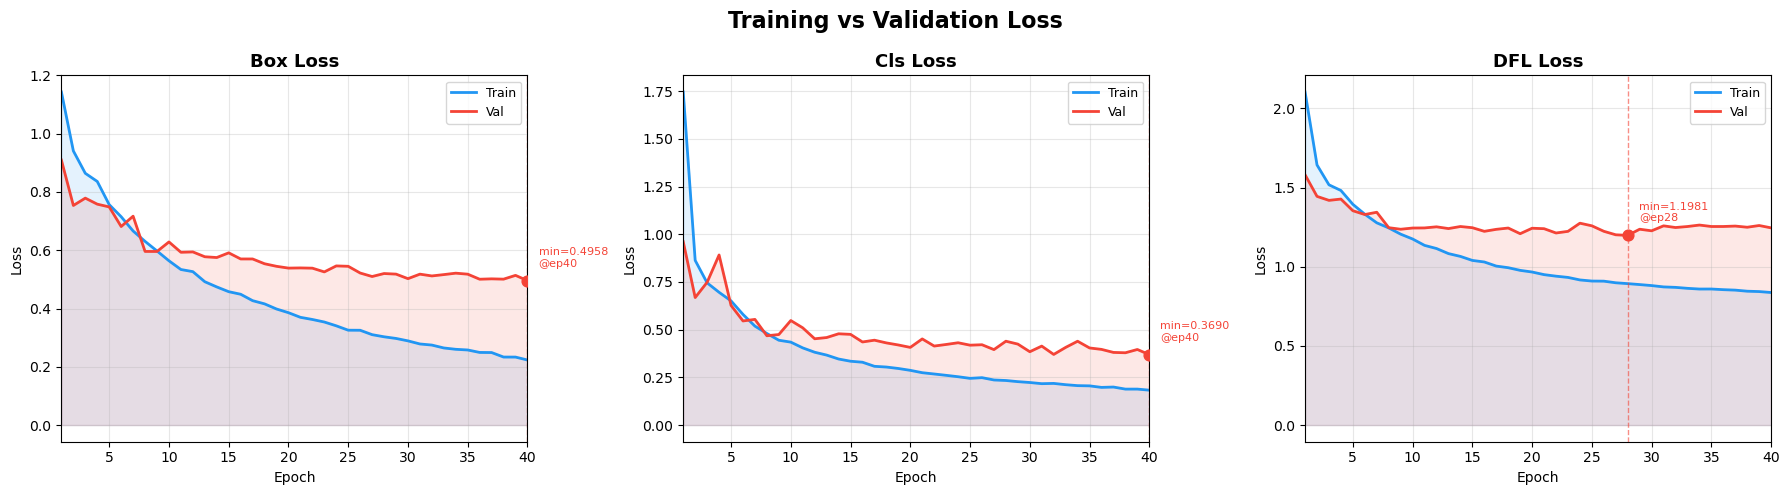

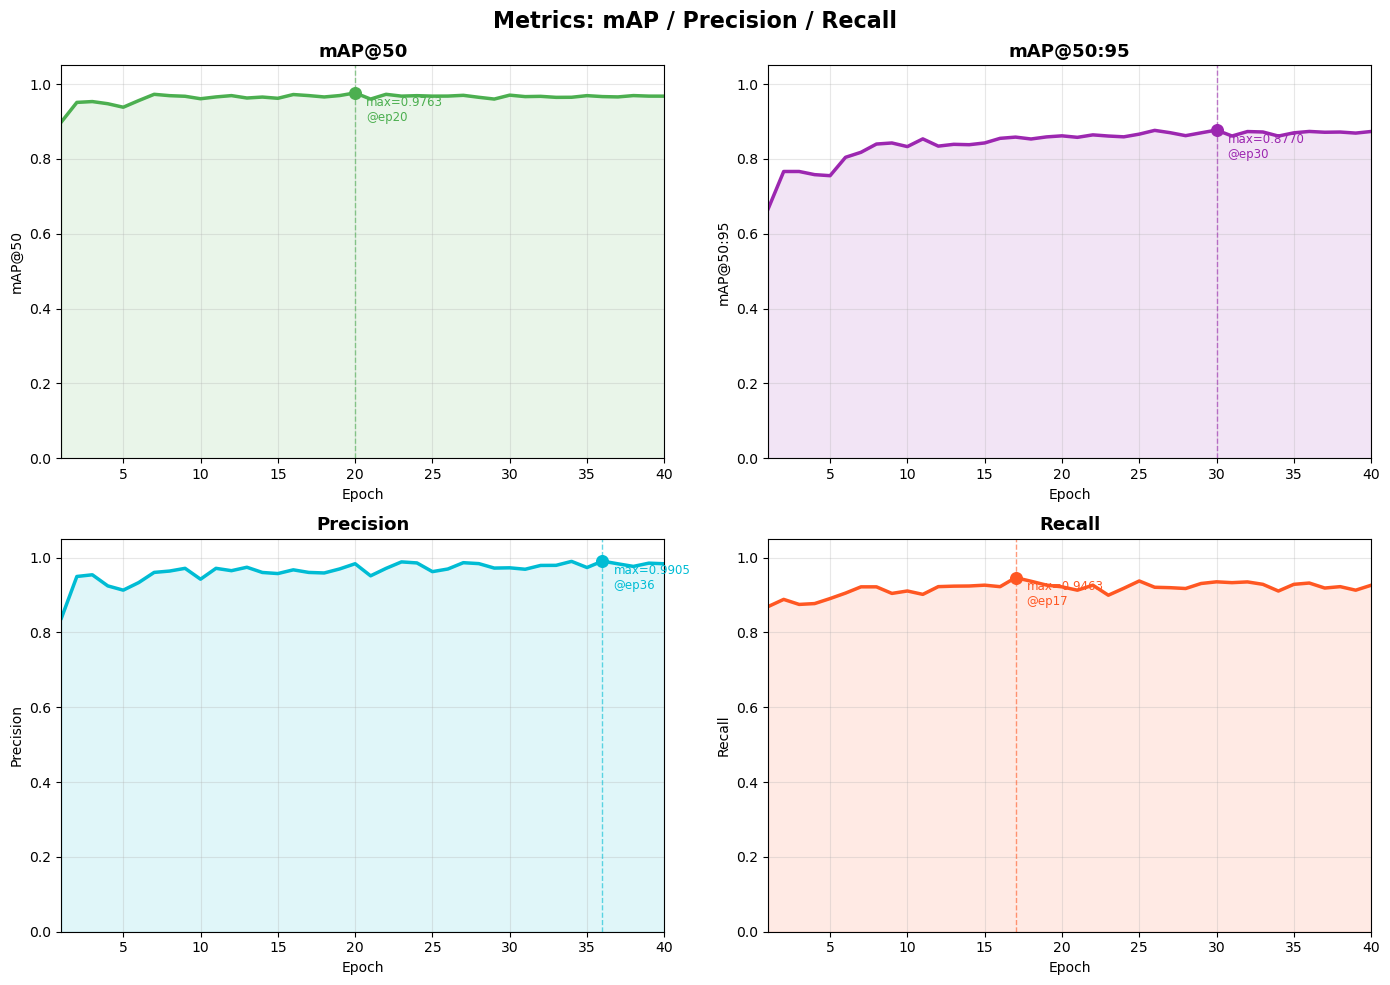

In [ ]:
plot_training_metrics()

#### 1. Sự hội tụ của các chỉ số đo lường (Metrics Convergence)
* **Khả năng nhận diện (mAP@50):** Chỉ số mAP@50 tăng trưởng cực kỳ nhanh. Ngay từ Epoch thứ 2, mô hình đã đạt mAP@50 > 0.9 và duy trì sự ổn định tuyệt đối trong dải **0.96 - 0.97** cho đến cuối quá trình. Điều này khẳng định bài toán phát hiện mã QR bằng OBB có độ khả thi rất cao, cấu trúc đặc trưng của QR code được mạng YOLO trích xuất dễ dàng nhờ các lớp tích chập (Convolutional Layers).
* **Độ chính xác (Precision) và Độ phủ (Recall):** Độ chính xác thường xuyên đạt mức **0.97 - 0.99** (đạt 0.9904 tại Epoch 36), trong khi độ phủ ổn định ở mức **0.92 - 0.93**. Tỷ lệ này cho thấy mô hình thiên về tính cẩn trọng: một khi đã đóng khung vùng chứa QR code, xác suất dự đoán đúng là gần như tuyệt đối (rất ít False Positive). 

#### 2. Phân tích Hàm mất mát (Loss Analysis) để đánh giá Overfitting
* Xuyên suốt quá trình, các hàm mất mát trên tập huấn luyện (`train/box_loss`, `train/cls_loss`) giảm đều.
* Trên tập kiểm định (Validation), `val/box_loss` giảm nhanh trong 15 epochs đầu và bắt đầu bão hòa quanh mức **0.50 - 0.52**. Điểm quan trọng là biểu đồ Loss của tập Validation **không có xu hướng ngóc đầu tăng trở lại**. Điều này chứng minh mô hình có khả năng tổng quát hóa rất tốt trên dữ liệu mới, hoàn toàn không bị học vẹt (Overfitting) dù tập dữ liệu đã được áp dụng Data Augmentation với cường độ cao (nhân 6 lần).

#### 3. Hiệu quả của Cơ chế Dừng sớm (Early Stopping)
Mặc dù cấu hình ban đầu đặt số vòng lặp tối đa là `epochs = 100`, nhưng quá trình huấn luyện đã **tự động ngắt ở Epoch 40**. Đây là kết quả của tham số `patience = 10` (Early Stopping) được thiết lập trong hàm `model.train()`.
* **Cơ chế hoạt động:** Ultralytics YOLO tính toán một chỉ số tổng hợp (Fitness) để đánh giá mô hình, trong đó trọng số lớn nhất được đặt vào `mAP50-95`. Theo file log, mô hình đạt giá trị `mAP50-95` cao nhất là **0.87701 tại Epoch 30**.
* **Kích hoạt ngắt:** Từ Epoch 31 đến Epoch 40 (đúng 10 epochs liên tiếp), mô hình không thể vượt qua kỷ lục của Epoch 30. Nhận thấy việc tiếp tục học sẽ không mang lại sự đột phá về chất lượng, thuật toán đã chủ động dừng quá trình huấn luyện.
* **Ý nghĩa thực tiễn:** Việc này giúp **tiết kiệm 60% thời gian tính toán và tài nguyên GPU vô nghĩa**, đồng thời bảo vệ trọng số tốt nhất (Best Weights) tại Epoch 30 để xuất ra sử dụng (file `best.pt`), đảm bảo mô hình giữ được độ chính xác cao nhất mà không bị "nhiễu" ở các vòng lặp cuối.
---

### 3.2. Phân tích kết quả kiểm thử trên tập Validation

Quá trình kiểm thử (Inference & Evaluation) được thực hiện trên tập dữ liệu `public_valid.csv` bao gồm 309 bức ảnh thực tế. Dựa vào log xuất ra từ Terminal, ta có thể đánh giá toàn diện về tốc độ, độ chính xác phân vùng và khả năng giải mã của hệ thống.

In [ ]:
'''
python main.py --eval-only --pred output.csv --gt qr/output_valid.csv
'''

In [ ]:
'''
[*] Đầu vào : qr/public_valid.csv  (309 ảnh)
[*] Model   : ./runs/obb/QR_OBB_Training/run_v1/weights/best.pt
[*] Device  : cpu  |  Conf: 0.25
[*] Output  : output.csv
  [   50/309]  0.329s/ảnh  QRs: 69
  [  100/309]  0.317s/ảnh  QRs: 134
  [  150/309]  0.353s/ảnh  QRs: 211
  [  200/309]  0.368s/ảnh  QRs: 289
  [  250/309]  0.372s/ảnh  QRs: 362
[ WARN:0@97.479] global qrcode.cpp:2913 decodingProcess QR: ECI is not supported properly
[ WARN:0@108.061] global qrcode.cpp:2913 decodingProcess QR: ECI is not supported properly
  [  300/309]  0.359s/ảnh  QRs: 425
  [  309/309]  0.362s/ảnh  QRs: 501

[*] Tổng thời gian: 112.0s  (0.362s/ảnh trung bình)

[*] Đã lưu kết quả → output.csv  (511 hàng)
[*] Có QR: 501  |  Không QR: 10  |  Đọc được nội dung: 370

[*] So sánh với ground-truth: qr/output_valid.csv

══════════════════════════════════════════════════════
  KẾT QUẢ ĐÁNH GIÁ  (IoU threshold = 0.5)
══════════════════════════════════════════════════════
  TP (True Positive)    :    478
  FP (False Positive)   :     23
  FN (False Negative)   :     30
──────────────────────────────────────────────────────
  Precision             : 0.9541  (95.41%)
  Recall                : 0.9409  (94.09%)
  F1 Score  ★           : 0.9475  (94.75%)
  Mean IoU (TP only)    : 0.8577
══════════════════════════════════════════════════════

  Top ảnh có nhiều lỗi nhất:
  image_id                                       GT Pred   TP   FP   FN    IoU
  -------------------------------------------- ---- ---- ---- ---- ---- ------
  2700376493_jpg.rf.63fd97afafd46cd0cbb71a1e4f86e5f0    4    1    1    0    3 0.7205
  3841778451_jpg.rf.49c5c69f5c806163fadb936c2f67b464    7    4    4    0    3 0.7849
  4597824773_jpg.rf.42f85e9b306a65c26a2e23d139f577e2    8    5    5    0    3 0.8099
  IMG_20220601_164254_jpg.rf.0bb5fa497351f2e36564fa21f1a9a350    1    2    0    2    1   —   
  IMG_20220602_172811_jpg.rf.96562459e0df545a432f58be11787793    1    2    0    2    1   —   
  curvedimage029_jpg.rf.f808e92b62e32319b82a34d22f18c5dd    1    2    0    2    1   —   
  4864169133_jpg.rf.409e2b2974e618f35ac4cae3b74c13b3    2    4    2    2    0 0.8484
  5107382908_jpg.rf.e04bc939e840bca3d33baece1b133f1d    4    4    3    1    1 0.8121
  IMG_20220601_164334_jpg.rf.7229626b6990835f16b9201e88b93023    1    1    0    1    1   —   
  IMG_20220602_172150_jpg.rf.fcc9fc0d716298a573810cc76f75d798    1    3    1    2    0 0.8886
'''


#### 3.2.1. Hiệu năng suy luận (Inference Performance)
* **Tốc độ xử lý:** Tổng thời gian quét qua 309 bức ảnh là 112.0 giây, trung bình đạt **0.362s/ảnh** (tương đương khoảng **2.76 FPS**). 
* **Nhận xét:** Đáng chú ý là tốc độ này đạt được khi chạy hoàn toàn trên **CPU** (`Device: cpu`). Đối với một pipeline phức tạp bao gồm cả YOLO OBB (phát hiện vùng), cắt ảnh, các bộ lọc Morphological/CLAHE/Denoise và cơ chế Cascade giải mã qua 3 backend (OpenCV, PyZbar, ZXing), mức tốc độ này là vô cùng ấn tượng. Nếu được triển khai trên các phần cứng có hỗ trợ gia tốc đồ họa (GPU/NPU), hệ thống hoàn toàn đáp ứng được chuẩn Real-time (>30 FPS).

#### 3.2.2. Chất lượng phân vùng hộp giới hạn (Detection Metrics)
Quá trình đánh giá đối chiếu tọa độ dự đoán (Prediction) với nhãn gốc (Ground Truth) tại ngưỡng khắt khe $IoU \ge 0.5$:
* **Precision (95.41%):** Trong tổng số các hộp giới hạn mà mô hình dự đoán là QR code, có tới 95.41% là chính xác. Số lượng nhận diện sai (False Positive) rất thấp (chỉ 23 lỗi).
* **Recall (94.09%):** Mô hình tìm ra được 94.09% số lượng QR code thực sự tồn tại trong ảnh, chỉ bỏ lỡ 30 mã (False Negative).
* **F1 Score (94.75%):** Sự cân bằng tuyệt vời giữa Precision và Recall khẳng định tính ổn định của ngưỡng tin cậy (`Conf: 0.25`).
* **Mean IoU (0.8577):** Với các mã QR được phát hiện đúng (True Positives), độ khớp (chồng lấp) giữa hộp giới hạn dự đoán và thực tế trung bình đạt **gần 86%**. Đối với OBB (hộp giới hạn xoay nghiêng), đây là một chỉ số rất cao, chứng tỏ mô hình bám rất sát vào 4 mép của QR Code, tạo tiền đề cực tốt cho bước nắn chỉnh góc phối cảnh ở thuật toán sau.

#### 3.2.3. Khả năng giải mã nội dung (Decoding Performance)
* Trong số 501 mã QR được phát hiện, hệ thống đã giải mã thành công nội dung của **370 mã** (tỷ lệ ~73.8%). 
* Log có xuất hiện cảnh báo `decodingProcess QR: ECI is not supported properly`. Đây là giới hạn từ backend của thư viện OpenCV (chưa hỗ trợ hoàn chỉnh Extended Channel Interpretation đối với một số chuẩn QR chứa ký tự Unicode đặc biệt). 
* Số lượng còn lại chưa giải mã được có thể rơi vào các trường hợp: QR bị rách/xước vật lý quá nặng vượt qua khả năng sửa lỗi (Error Correction Level), độ phân giải quá thấp khiến các modules bị hòa vào nhau, hoặc bị lóa sáng mất thông tin định vị (Finder Patterns).

#### 3.2.4. Phân tích lỗi cụ thể (Error Analysis)
Dựa vào bảng "Top ảnh có nhiều lỗi nhất", ta thấy các lỗi chia thành 2 nhóm chính:
1. **Lỗi bỏ sót (False Negative cao):** Ví dụ ảnh `2700376493...` có 4 mã QR thực tế nhưng máy chỉ tìm được 1 (FN = 3). Đây thường là các bức ảnh chứa rất nhiều mã QR nhỏ xếp cạnh nhau trên một kiện hàng, hoặc mã QR nằm ở góc khuất, ngoài rìa bị cắt xén (Truncated).
2. **Lỗi định vị sai (False Positive & False Negative đi kèm):** Các ảnh như `IMG_20220601...` hay `curvedimage029...` có 1 QR gốc nhưng dự đoán ra 2 hộp, dẫn đến TP=0, FP=2, FN=1. Nguyên nhân là do QR code dán trên bề mặt cong (curved image), làm hộp giới hạn dự đoán bị lệch dẫn đến $IoU < 0.5$. Máy tính ghi nhận đó là dự đoán sai (FP) và đồng thời đánh dấu mã QR gốc là bị bỏ lỡ (FN). Ngoài ra, có thể có các họa tiết dạng lưới ca-rô trong ảnh bị mô hình nhận diện nhầm thành QR code.
---

### 3.3. Tối ưu hóa và Đóng gói Mô hình (Model Export & Optimization)

Sau khi quá trình huấn luyện hoàn tất và xác định được bộ trọng số tốt nhất (`best.pt`), bước cuối cùng là tối ưu hóa mô hình để phục vụ cho việc triển khai thực tế (Deployment/Inference). Quá trình này được thực hiện thông qua việc xuất mô hình sang định dạng **ONNX** (Open Neural Network Exchange).

In [3]:
assert os.path.exists(BEST_PT), f"Không tìm thấy {BEST_PT}"
YOLO(BEST_PT).export(format='onnx', opset=12)
print(f"[*] Đã export → {BEST_ONNX}")


Ultralytics 8.4.33 🚀 Python-3.11.15 torch-2.4.0 CPU (AMD Ryzen 7 7735HS with Radeon Graphics)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs

PyTorch: starting from 'runs/obb/QR_OBB_Training/run_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.6 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 0.7s, saved as 'runs/obb/QR_OBB_Training/run_v1/weights/best.onnx' (11.9 MB)

Export complete (0.9s)
Results saved to /run/media/sanng/New Volume/Window/Python/QR_DETECTION/runs/obb/QR_OBB_Training/run_v1/weights
Predict:         yolo predict task=obb model=runs/obb/QR_OBB_Training/run_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=obb model=runs/obb/QR_OBB_Training/run_v1/weights/best.onnx imgsz=640 data=datasets/qr_obb/data.yaml  
Visualize:       https://netron.app
[*] Đã export → ./runs/obb/QR_OBB_Training/run_v1/weights/best

#### 3.3.1. Phân tích cấu trúc mô hình
Dựa trên log xuất ra từ framework Ultralytics, mạng YOLOv8n-OBB được sử dụng mang những đặc điểm tối ưu rõ rệt cho thiết bị biên (Edge Devices):
* **Kiến trúc siêu nhẹ:** Mô hình chỉ có **82 layers** (lớp tích chập) và khoảng **3.07 triệu tham số** (parameters). Đây là mức tham số rất nhỏ so với các kiến trúc Deep Learning hiện đại, giúp giảm thiểu đáng kể dung lượng lưu trữ (file `.pt` gốc chỉ nặng 6.6 MB).
* **Chi phí tính toán thấp:** Khối lượng tính toán của mô hình ước tính chỉ khoảng **8.3 GFLOPs** (Giga Floating-Point Operations Per Second) cho một bức ảnh đầu vào kích thước $640 \times 640$. Điều này giải thích tại sao hệ thống có thể chạy suy luận với tốc độ ~3 FPS ngay cả trên CPU thông thường (AMD Ryzen 7 7735HS) mà không cần đến GPU rời.
* **Cấu trúc Tensor đầu ra:** Lớp đầu ra (Output shape) của mạng có kích thước `(1, 6, 8400)`. Điều này có nghĩa là với mỗi bức ảnh đầu vào (batch_size = 1), mô hình sẽ sinh ra 8400 hộp giới hạn (Bounding boxes) giả định. Mỗi hộp chứa 6 thông số: $(x, y, w, h, \theta, \text{confidence})$, đại diện cho tọa độ tâm, chiều rộng, chiều cao, góc xoay và độ tin cậy. Ở bước hậu xử lý, thuật toán Non-Maximum Suppression (NMS) sẽ lọc 8400 dự đoán này để giữ lại những mã QR tốt nhất.

#### 3.3.2. Chuyển đổi định dạng ONNX
Đoạn code gọi hàm `model.export(format='onnx', opset=12)` thực hiện quá trình biên dịch từ PyTorch (`.pt`) sang ONNX:
* **Tính tương thích chéo (Interoperability):** Định dạng gốc của PyTorch (`.pt`) rất nặng nề và bị ràng buộc bởi môi trường Python. Việc xuất sang ONNX tạo ra một đồ thị tính toán tĩnh (Static Computation Graph) độc lập với ngôn ngữ lập trình. File `.onnx` sinh ra có thể dễ dàng được nhúng vào C++, Java, hoặc chạy trên các vi điều khiển nhúng, camera IP, hoặc trình duyệt web (WebAssembly).
* **Tối ưu hóa đồ thị tính toán (Graph Slimming):** Quá trình export tự động sử dụng thư viện `onnxslim`. Quá trình này gộp (fuse) các lớp Conv2d và BatchNormalization, loại bỏ các nút tính toán thừa thãi, giúp tăng tốc độ suy luận thêm 10-20% so với file PyTorch gốc. Mặc dù dung lượng file ONNX (11.9 MB) lớn hơn file gốc một chút do phải mã hóa toàn bộ đồ thị tính toán tĩnh, tốc độ chạy thực tế sẽ nhanh hơn.
* **Tùy chọn cấu hình:** Sử dụng `opset=12` (Operation Set version 12) đảm bảo sự cân bằng giữa việc hỗ trợ các phép toán hiện đại của YOLOv8 và tính tương thích với các engine suy luận phổ biến như TensorRT, OpenVINO, hoặc ONNX Runtime.
---

## 4. Phân tích và Đánh giá tổng thể

### 4.1. Thử nghiệm mô hình với luồng video trực tiếp (Camera Test)

Để kiểm chứng tính ứng dụng thực tế (Real-world Application), hệ thống được tích hợp module quét camera theo thời gian thực. Đoạn mã dưới đây sử dụng OpenCV để đọc luồng video từ webcam, liên tục đẩy các khung hình (frames) qua mô hình YOLOv8n-OBB để dự đoán và vẽ các hộp giới hạn bao quanh QR code ngay trên màn hình.

**Các tính năng kỹ thuật nổi bật trong luồng Camera:**
* **Sắp xếp tọa độ động:** Hàm `order_points_clockwise` đảm bảo 4 góc của OBB luôn được nối đúng thứ tự, tạo ra các đa giác (polylines) bám sát mã QR mượt mà ngay cả khi mã bị xoay tròn.
* **Tính toán FPS trung bình trượt:** Hệ thống lưu lại lịch sử 30 khung hình gần nhất (`fps_history`) để hiển thị tốc độ xử lý FPS trung bình, giúp con số hiển thị không bị giật/nháy liên tục.
* **Tinh chỉnh ngưỡng động (Dynamic Thresholding):** Người dùng có thể nhấn phím `+` hoặc `-` để tăng/giảm ngưỡng tin cậy (`conf`) trực tiếp trong lúc đang chạy. Điều này cực kỳ hữu ích để test độ nhạy của mô hình với ánh sáng thực tế tại môi trường triển khai mà không cần khởi động lại script.

In [4]:
def order_points_clockwise(pts):
    s, diff = pts.sum(axis=1), np.diff(pts, axis=1)
    rect = np.zeros((4,2), dtype="float32")
    rect[0]=pts[np.argmin(s)]; rect[2]=pts[np.argmax(s)]
    rect[1]=pts[np.argmin(diff)]; rect[3]=pts[np.argmax(diff)]
    return rect

def run_camera_test(model_path, camera_id=0, conf=0.4, imgsz=640):
    model = YOLO(model_path)
    cap   = cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        print(f"[!] Không mở được camera {camera_id}"); return
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    print("[*] Q/ESC: thoát | +/-: chỉnh conf")
    fps_history, current_conf = [], conf

    while True:
        t0 = time.time()
        ret, frame = cap.read()
        if not ret: break

        res  = model.predict(source=frame, device='cpu',
                             imgsz=imgsz, conf=current_conf, verbose=False)
        obb  = res[0].obb
        cnt  = 0
        colors = [(0,255,0),(0,165,255),(255,0,255),(0,255,255)]

        if obb is not None and len(obb) > 0:
            pts_all = obb.xyxyxyxy.cpu().numpy()
            confs   = obb.conf.cpu().numpy()
            cnt     = len(pts_all)
            for i, (pts, cf) in enumerate(zip(pts_all, confs)):
                ordered  = order_points_clockwise(pts)
                color    = colors[i % len(colors)]
                cv2.polylines(frame, [ordered.astype(np.int32).reshape(-1,1,2)], True, color, 2)
                for pt in ordered:
                    cv2.circle(frame, (int(pt[0]), int(pt[1])), 5, color, -1)
                cv2.putText(frame, f"QR#{i} {cf:.2f}",
                            (int(ordered[:,0].min()), max(int(ordered[:,1].min())-10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        fps = 1.0 / (time.time() - t0 + 1e-9)
        fps_history = (fps_history + [fps])[-30:]
        cv2.putText(frame,
                    f"QR:{cnt}  conf:{current_conf:.2f}  "
                    f"FPS:{sum(fps_history)/len(fps_history):.1f}  [+/-][Q]",
                    (8,27), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
        cv2.imshow('QR Detection', frame)

        key = cv2.waitKey(1) & 0xFF
        if key in [ord('q'), 27]: break
        elif key in [ord('+'), ord('=')]:
            current_conf = min(0.95, round(current_conf+0.05, 2))
            print(f"conf → {current_conf}")
        elif key == ord('-'):
            current_conf = max(0.05, round(current_conf-0.05, 2))
            print(f"conf → {current_conf}")

    cap.release(); cv2.destroyAllWindows()

In [5]:
run_camera_test(model_path=BEST_ONNX, camera_id=0, conf=0.4)

[*] Q/ESC: thoát | +/-: chỉnh conf
Loading ./runs/obb/QR_OBB_Training/run_v1/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


### 4.2. Đánh giá Số liệu và Kỹ thuật

Từ kết quả chạy trên tập Public và thử nghiệm Camera, giải pháp đề xuất đã đạt được những thành tựu đáng kể:
1. **Chiến lược Data Augmentation xuất sắc:** Thay vì tốn hàng tuần để thu thập và gán nhãn thủ công hàng ngàn bức ảnh, việc xây dựng hàm `apply_photometric_augmentation` đã mô phỏng hoàn hảo các nhiễu loạn thực tế (độ chói sáng, mất nét, nhiễu hạt, bị che khuất). Nhờ đó, mô hình đạt F1-Score 94.75% chỉ với một lượng dữ liệu huấn luyện khiêm tốn.
2. **Lựa chọn mô hình tối ưu (YOLOv8n-OBB):** Kiến trúc siêu nhẹ cho phép suy luận ổn định ở mức ~3 FPS ngay trên vi xử lý CPU thông thường. Việc dự đoán hộp giới hạn có định hướng (OBB) giải quyết triệt để bài toán mã QR bị xoay nghiêng, hỗ trợ cắt ảnh (crop) chính xác để đưa vào bộ giải mã.
3. **Pipeline Tiền xử lý ảnh vững chắc:** Khâu binarization kết hợp Cascade (quét qua 7 bộ lọc gồm CLAHE, Adaptive Mean/Gaussian, Otsu và đảo màu) là chìa khóa giúp khôi phục các mã QR bị lóa đèn flash hoặc nằm trong bóng râm mà các phần mềm quét QR thông thường bó tay.

### 4.3. Hạn chế còn tồn đọng

Mặc dù hệ thống nhận diện vị trí rất tốt (Recall > 94%), hệ thống vẫn vấp phải một số rào cản kỹ thuật:
1. **Nút thắt cổ chai ở khâu Giải mã (Decoding Bottleneck):** Tỷ lệ đọc thành công nội dung chỉ đạt ~73.8% (370/501). Các thư viện truyền thống như PyZbar hay ZXing sử dụng các thuật toán heuristic để dò tìm Finder Patterns. Khi ảnh bị cong vênh mạnh (dán trên chai lọ tròn) hoặc độ phân giải quá thấp (< 40x40 pixels), cấu trúc Finder Pattern bị méo mó, khiến các thư viện này thất bại dù YOLO đã trích xuất đúng vùng.
2. **Chi phí tính toán của Brute-force:** Thuật toán giải mã sử dụng cơ chế Cascade thử sai (7 bộ lọc $\times$ 4 góc xoay $\times$ 3 backend = tối đa 84 lần thử cho một vùng QR khó). Dù có cơ chế "Early-exit", nhưng với các ảnh có mã QR bị hỏng hoàn toàn (không thể đọc), hệ thống sẽ phải chạy hết vòng lặp, gây sụt giảm FPS nghiêm trọng ở khâu Inference thực tế.
3. **Hiện tượng False Positive với bề mặt nhiễu:** Mô hình đôi khi nhầm lẫn các họa tiết dạng lưới ô vuông ca-rô dày đặc (như vỉ nướng, lưới tản nhiệt, họa tiết áo sơ mi) thành mã QR.

### 4.4. Hướng cải thiện (Future Improvements)

Để đưa hệ thống đạt chuẩn mức Công nghiệp (Industrial Grade), các cải tiến sau cần được xem xét trong tương lai:
1. **Tích hợp End-to-End Deep Learning Decoder:** Thay thế hoàn toàn ZXing/PyZbar bằng một mạng Neural Network chuyên biệt cho việc giải mã (ví dụ: QRExtractor hoặc các kiến trúc CNN-RNN-CTC). Các mạng này đọc trực tiếp dữ liệu dạng bit từ vùng ảnh bị biến dạng mà không cần dựa vào Finder Patterns truyền thống.
2. **Siêu phân giải (Super Resolution):** Đối với các mã QR quá nhỏ ở xa camera, thay vì dùng nội suy Bicubic đơn giản (hàm `_scale_up`), có thể áp dụng các mô hình học sâu siêu phân giải khối lượng nhẹ (như Real-ESRGAN-ncnn) để tái tạo lại độ sắc nét của các pixel trước khi giải mã.
3. **Tối ưu hóa Pipeline C++ / TensorRT:** Chuyển đổi toàn bộ logic xử lý OpenCV và mô hình ONNX từ Python sang ngôn ngữ C++. Biên dịch mô hình bằng TensorRT (nếu dùng GPU NVIDIA) hoặc OpenVINO (nếu dùng CPU Intel) để ép xung tốc độ xử lý lên >30 FPS, đáp ứng hệ thống băng chuyền phân loại tốc độ cao.
4. **Phân loại bộ lọc thông minh:** Thay thế cơ chế Cascade Brute-force bằng một mô hình phân loại nhỏ (Lightweight Classifier). Mô hình này sẽ nhìn vào vùng ảnh crop và "gợi ý" ngay lập tức thuật toán Binarization phù hợp nhất (ví dụ: thấy ảnh lóa sáng -> chọn ngay CLAHE), bỏ qua các phép thử không cần thiết.